In [57]:
import pandas as pd
import os 
import numpy as np
os.chdir("/home/fitsl/dev/bayesketball") ## change to your root
os.getcwd()
import seaborn as sns
from matplotlib import pyplot as plt

In [33]:
posterior_samples = pd.read_csv("results/general_attempt_non_possession_posterior.csv")
posterior_samples

,alpha,beta[1],beta[2],beta[3],beta[4],beta[5],beta[6],beta[7],beta[8],beta[9],beta[10],sigma,lp__
0,0.074915,0.207819,0.267665,0.218299,-0.271525,1.526234,0.497729,0.186531,0.158345,-1.150823,-0.022397,6.184658,-52143.126424
1,0.030601,0.230686,0.252056,0.192735,-0.298654,1.534250,0.475221,0.142299,0.157681,-1.160529,-0.081489,6.168794,-52145.275995
2,0.085696,0.235558,0.264910,0.196672,-0.296581,1.537627,0.488018,0.193044,0.163367,-1.127697,-0.083700,6.169675,-52145.029911
3,0.133013,0.192306,0.255917,0.213140,-0.251115,1.525462,0.498847,0.129271,0.146819,-1.195214,-0.020203,6.171621,-52141.454646
4,0.052054,0.188909,0.264571,0.191655,-0.242998,1.535693,0.472232,0.170503,0.141432,-1.174051,-0.047202,6.202736,-52141.269239
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.047307,0.208874,0.256561,0.194336,-0.283626,1.535520,0.482115,0.182224,0.136158,-1.165049,-0.064205,6.199813,-52139.465486
1996,0.100365,0.208792,0.271968,0.209621,-0.269107,1.524842,0.490626,0.173106,0.132553,-1.141160,-0.051812,6.157074,-52140.800095
1997,0.073975,0.202201,0.263480,0.190746,-0.277766,1.526281,0.497513,0.166961,0.133854,-1.168225,-0.072282,6.154847,-52139.553959
1998,0.034654,0.212573,0.259965,0.212449,-0.281925,1.522514,0.492720,0.189548,0.169035,-1.151808,-0.029631,6.196272,-52143.096855


In [58]:
test_x_h = pd.read_csv("data/general_attempt_non_possession/x_h_test.csv")
test_x_a = pd.read_csv("data/general_attempt_non_possession/x_a_test.csv")
test_y  = pd.read_csv("data/general_attempt_non_possession/y_test.csv")

test_y.columns

Index(['plus_minus_home'], dtype='object')

In [46]:
test_x_h.iloc[0].to_numpy()

array([80., 32., 25.,  5., 28., 27.,  5.,  6., 11., 21.])

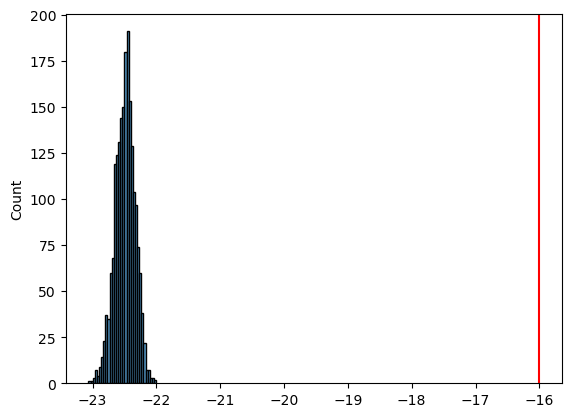

In [84]:
def predict_diff(posterior_samples, x_h, x_a, y, idx):

    predictions = [] 
    for _, sample_row in posterior_samples.iterrows():
        betas = [f"beta[{i}]" for i in range(1,11)]
        betas = sample_row[betas].to_numpy()

        alpha = sample_row['alpha']

        result = alpha + np.sum(betas*x_h.iloc[idx].to_numpy()) - np.sum(betas*x_a.iloc[idx].to_numpy())
        predictions.append(result)

    sns.histplot(predictions)
    actual = y.iloc[idx]['plus_minus_home']
    plt.axvline(actual, color="red")

predict_diff(posterior_samples, test_x_h, test_x_a, test_y, 0)